# BRSET Glaucoma — Phase 3 Patient Pooling on Cleaned Embeddings

**Goal:** Run Phase 3 (patient-level embedding pooling + MLP BayesSearchCV) on the
**cleaned BRSET embeddings** (2,012 bad-quality images removed) and compare against
the original Phase 1/2 results on uncleaned data.

## Cleaning applied
- **Quality filter**: 1,987 images labelled "Inadequate" removed
- **Embedding consensus**: 25 additional images flagged as L2-norm IQR outliers by ≥3 of 7 embeddings
- **Remaining**: 14,254 images, 8,061 patients (glaucoma+ rate preserved at 19.9%)

## Phase 3 strategy: pool first, classify once
1. Per patient: compute **mean + std** of image embeddings → 2×D features
2. Patient label = mode of image labels
3. MLP with BayesSearchCV on patient-level features (no image-level aggregation needed)
4. F1-optimal threshold on internal validation set

**Patient split**: Reuse the frozen 80/20 split from the original experiment for direct comparison.

## 1. Setup and Imports

In [1]:
import os
import json
import copy
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import Normalize

from skopt import BayesSearchCV
from skopt.space import Categorical, Integer, Real
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import (
    log_loss,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
    balanced_accuracy_score,
)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, ClassifierMixin

import sys
sys.path.insert(0, str(Path.cwd() / 'src'))
import src.retina_evaluation as reval
from src.retina_benchmark import list_embeddings_csvs
from src.retina_embeddings_dataset import load_retina_embeddings_dataset

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

plt.style.use('seaborn-v0_8-whitegrid')

print('Imports complete.')

Imports complete.


## 2. Configuration

In [2]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 2 — Configuration
# ═══════════════════════════════════════════════════════════════════════════════
PROJECT_ROOT = Path.cwd()
DATASET_NAME = 'brset'
RANDOM_SEED = 42
TEST_FRAC = 0.2

# Task
TASK = 'increased_cup_disc'
DISPLAY_TASK = 'glaucoma_detection'

CPU_COUNT = os.cpu_count() or 1

# ★ CLEANED EMBEDDINGS ★
EMBED_DIR_CLEAN = PROJECT_ROOT / 'data' / 'brset_embeddings_cleaned'
LABELS_PATH_CLEAN = EMBED_DIR_CLEAN / 'brset_labels' / 'labels_brset.csv'

# Original (for reference)
EMBED_DIR_ORIG = PROJECT_ROOT / 'data' / 'brset_embeddings'
LABELS_PATH_ORIG = EMBED_DIR_ORIG / 'brset_labels' / 'labels_brset.csv'

# Results
RESULTS_DIR_ORIG = PROJECT_ROOT / 'results' / 'brset_patient_eval_glaucoma'
RESULTS_DIR = PROJECT_ROOT / 'results' / 'brset_glaucoma_cleaned_phase3'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Frozen patient split from original experiment
SPLIT_CSV = RESULTS_DIR_ORIG / 'patient_split.csv'

# ─── Phase 3 Bayesian search config ────────────────────────────────────────
PHASE3_N_ITER = 30
PHASE3_MAX_EPOCHS = 300
PHASE3_PATIENCE = 25
PHASE3_CV_FOLDS = 3
BAYES_N_JOBS = min(3, CPU_COUNT)

# Architecture options (14 options, suitable for 2×D pooled features)
PHASE3_ARCHITECTURES = [
    (128,),
    (256,),
    (512,),
    (1024,),
    (128, 128),
    (256, 128),
    (256, 256),
    (512, 256),
    (512, 512),
    (1024, 512),
    (128, 128, 128),
    (256, 256, 128),
    (512, 256, 128),
    (1024, 512, 256),
]

PHASE3_SEARCH_SPACE = {
    'hidden_layer_sizes': Integer(0, len(PHASE3_ARCHITECTURES) - 1, name='hidden_layer_sizes'),
    'alpha': Real(1e-5, 1e-1, prior='log-uniform', name='alpha'),
    'learning_rate_init': Real(5e-5, 2e-3, prior='log-uniform', name='learning_rate_init'),
    'batch_size': Categorical([32, 64, 128, 256], name='batch_size'),
    'pos_class_weight': Real(1.0, 10.0, prior='uniform', name='pos_class_weight'),
}

THRESHOLD_GRID_SIZE = 201
SHOW_PLOTS = True
SAVE_PLOTS = True

print(f'Project root: {PROJECT_ROOT}')
print(f'Cleaned embeddings: {EMBED_DIR_CLEAN}')
print(f'Results: {RESULTS_DIR}')
print(f'Phase 3: {PHASE3_N_ITER} Bayesian iters, {PHASE3_CV_FOLDS} CV folds, scoring=f1')
print(f'Architectures: {len(PHASE3_ARCHITECTURES)} options')
print(f'Weight search: 1.0–10.0, alpha: 1e-5–1e-1, lr: 5e-5–2e-3')
print(f'Batch sizes: [32, 64, 128, 256]')

Project root: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project
Cleaned embeddings: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\data\brset_embeddings_cleaned
Results: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_glaucoma_cleaned_phase3
Phase 3: 30 Bayesian iters, 3 CV folds, scoring=f1
Architectures: 14 options
Weight search: 1.0–10.0, alpha: 1e-5–1e-1, lr: 5e-5–2e-3
Batch sizes: [32, 64, 128, 256]


## 3. Load Cleaned Embeddings and Patient Split

In [3]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 3 — Load cleaned embeddings and reuse frozen patient split
# ═══════════════════════════════════════════════════════════════════════════════

# List cleaned embedding files
embedding_files = sorted(EMBED_DIR_CLEAN.glob('Embeddings_*.csv'))
print(f'Found {len(embedding_files)} cleaned embedding files:')
for i, emb in enumerate(embedding_files):
    print(f'  {i}: {emb.name}')

# Load cleaned labels
clean_labels = pd.read_csv(LABELS_PATH_CLEAN)
print(f'\nCleaned labels: {len(clean_labels)} images, {clean_labels["patient_id"].nunique()} patients')
print(f'Glaucoma distribution:')
print(clean_labels[TASK].value_counts())
print(f'Positive rate: {clean_labels[TASK].mean():.1%}')

# Load frozen patient split from original experiment
split_df = pd.read_csv(SPLIT_CSV)
split_df['patient_id'] = split_df['patient_id'].astype(str)
orig_train_ids = set(split_df[split_df['split'] == 'train']['patient_id'])
orig_test_ids = set(split_df[split_df['split'] == 'test']['patient_id'])

# Intersect with surviving patients in cleaned data
clean_pids = set(clean_labels['patient_id'].astype(str).unique())
train_patient_ids = orig_train_ids & clean_pids
test_patient_ids = orig_test_ids & clean_pids

dropped_train = orig_train_ids - clean_pids
dropped_test = orig_test_ids - clean_pids

print(f'\nOriginal split: {len(orig_train_ids)} train / {len(orig_test_ids)} test')
print(f'Dropped by cleaning: {len(dropped_train)} train, {len(dropped_test)} test')
print(f'Cleaned split: {len(train_patient_ids)} train / {len(test_patient_ids)} test')
assert len(train_patient_ids & test_patient_ids) == 0, 'LEAKAGE!'
print('No patient overlap (no leakage) ✓')

# Glaucoma prevalence in cleaned test set
clean_labels['patient_str'] = clean_labels['patient_id'].astype(str)
test_labs = clean_labels[clean_labels['patient_str'].isin(test_patient_ids)]
glaucoma_pos = test_labs.groupby('patient_str')[TASK].max().sum()
print(f'Test set: {int(glaucoma_pos)} glaucoma+ / {len(test_patient_ids)} total ({glaucoma_pos/len(test_patient_ids)*100:.1f}%)')

# Save cleaned split
clean_split_info = pd.DataFrame({
    'patient_id': list(train_patient_ids) + list(test_patient_ids),
    'split': ['train'] * len(train_patient_ids) + ['test'] * len(test_patient_ids),
})
clean_split_info.to_csv(RESULTS_DIR / 'patient_split.csv', index=False)
print(f'Saved cleaned split: {RESULTS_DIR / "patient_split.csv"}')

Found 7 cleaned embedding files:
  0: Embeddings_brset_convnextv2_base_.csv
  1: Embeddings_brset_dinov3_convnext_base.csv
  2: Embeddings_brset_dinov3_vitb16.csv
  3: Embeddings_brset_RETFound_dinov2_shanghai.csv
  4: Embeddings_brset_RETFound_mae_natureCFP.csv
  5: Embeddings_brset_RETFound_mae_shanghai.csv
  6: Embeddings_brset_vit_base_.csv

Cleaned labels: 14254 images, 8061 patients
Glaucoma distribution:
increased_cup_disc
0    11418
1     2836
Name: count, dtype: int64
Positive rate: 19.9%

Original split: 6819 train / 1705 test
Dropped by cleaning: 383 train, 80 test
Cleaned split: 6436 train / 1625 test
No patient overlap (no leakage) ✓
Test set: 392 glaucoma+ / 1625 total (24.1%)
Saved cleaned split: c:\Users\Julian\OneDrive\Desktop\testing-retina-project\Retina-Project-Evaluation\main-project\results\brset_glaucoma_cleaned_phase3\patient_split.csv


## 4. Helper Functions

In [4]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 4 — Helper Functions
# ═══════════════════════════════════════════════════════════════════════════════

def make_sample_weights(y, pos_class_weight=1.0):
    """Build per-sample weights: neg=1.0, pos=pos_class_weight, normalized."""
    y = np.asarray(y)
    w = np.where(y == 1, float(pos_class_weight), 1.0).astype(np.float32)
    mean_w = w.mean()
    if mean_w > 0:
        w /= mean_w
    return w


def find_optimal_threshold(y_true, y_proba, method='f1', grid_size=201):
    """Find F1-optimal binary classification threshold."""
    y_true = np.asarray(y_true)
    y_proba = np.asarray(y_proba)
    if y_true.size == 0:
        return 0.5
    thresholds = np.linspace(0.01, 0.99, grid_size)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)
        f1 = float(f1_score(y_true, y_pred, zero_division=0))
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t


class MLPWrapperForBayesSearch(BaseEstimator, ClassifierMixin):
    """Wrapper that converts integer arch indices to tuples and applies class weights."""
    def __init__(self, hidden_layer_sizes=0, alpha=0.01, learning_rate_init=0.001,
                 batch_size=64, pos_class_weight=1.0,
                 max_iter=300, early_stopping=True, validation_fraction=0.15,
                 n_iter_no_change=25, random_state=42, warm_start=False):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.alpha = alpha
        self.learning_rate_init = learning_rate_init
        self.batch_size = batch_size
        self.pos_class_weight = pos_class_weight
        self.max_iter = max_iter
        self.early_stopping = early_stopping
        self.validation_fraction = validation_fraction
        self.n_iter_no_change = n_iter_no_change
        self.random_state = random_state
        self.warm_start = warm_start
        self._mlp = None

    def _get_architecture(self):
        if isinstance(self.hidden_layer_sizes, int):
            return PHASE3_ARCHITECTURES[self.hidden_layer_sizes]
        return self.hidden_layer_sizes

    def fit(self, X, y, sample_weight=None):
        arch = self._get_architecture()
        self._mlp = MLPClassifier(
            hidden_layer_sizes=arch,
            alpha=self.alpha,
            learning_rate_init=self.learning_rate_init,
            batch_size=self.batch_size,
            max_iter=self.max_iter,
            early_stopping=self.early_stopping,
            validation_fraction=self.validation_fraction,
            n_iter_no_change=self.n_iter_no_change,
            random_state=self.random_state,
            warm_start=self.warm_start,
        )
        sw = make_sample_weights(y, pos_class_weight=self.pos_class_weight)
        self._mlp.fit(X, y, sample_weight=sw)
        self.classes_ = self._mlp.classes_
        self.n_iter_ = self._mlp.n_iter_
        self.loss_ = self._mlp.loss_
        self.best_loss_ = getattr(self._mlp, 'best_loss_', None)
        return self

    def predict(self, X):
        return self._mlp.predict(X)

    def predict_proba(self, X):
        return self._mlp.predict_proba(X)

    def score(self, X, y, sample_weight=None):
        return self._mlp.score(X, y, sample_weight=sample_weight)


def build_patient_pooled_features(df, feature_cols, group_col='patient_id',
                                  label_col='increased_cup_disc'):
    """
    Pool image-level embeddings to patient level: mean + std → 2×D.
    Label = mode of image-level labels.
    """
    patient_ids, X_pooled_list, y_labels = [], [], []
    for pid, group in df.groupby(group_col):
        features = group[feature_cols].to_numpy(dtype=np.float32)
        feat_mean = features.mean(axis=0)
        feat_std = features.std(axis=0) if len(features) > 1 else np.zeros_like(feat_mean)
        pooled = np.concatenate([feat_mean, feat_std])
        label = int(group[label_col].mode().iloc[0])
        patient_ids.append(pid)
        X_pooled_list.append(pooled)
        y_labels.append(label)
    return (
        np.array(patient_ids),
        np.array(X_pooled_list, dtype=np.float32),
        np.array(y_labels, dtype=int),
    )


def short_name(path):
    """Extract short embedding name."""
    stem = Path(path).stem
    for s in ['Embeddings_brset_', 'Embeddings_']:
        stem = stem.replace(s, '')
    return stem


def plot_confusion_matrix(cm, title, save_path=None, show=True):
    cm = np.asarray(cm)
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    im = ax.imshow(cm, cmap='viridis', interpolation='nearest')
    ax.set_title(title, fontsize=11, pad=12)
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('True', fontsize=10)
    ax.set_xticks(range(cm.shape[1]))
    ax.set_yticks(range(cm.shape[0]))
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Count', fontsize=9)
    thresh = cm.max() / 2.0
    for (i, j), val in np.ndenumerate(cm):
        ax.text(j, i, f'{val}', ha='center', va='center',
                color='white' if val > thresh else 'black', fontsize=10, fontweight='bold')
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)


def plot_roc_curve(fpr, tpr, auc, title, save_path=None, show=True):
    fig, ax = plt.subplots(figsize=(5.2, 4.6))
    points = np.array([fpr, tpr]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = Normalize(vmin=0.0, vmax=1.0)
    lc = LineCollection(segments, cmap='plasma', norm=norm)
    lc.set_array(fpr)
    lc.set_linewidth(2.6)
    ax.add_collection(lc)
    ax.plot([0, 1], [0, 1], linestyle='--', color='#666', linewidth=1.2, label='Chance')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_title(f'{title}\nAUC = {auc:.3f}', fontsize=11, pad=12)
    ax.set_xlabel('False Positive Rate', fontsize=10)
    ax.set_ylabel('True Positive Rate', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    cbar = fig.colorbar(lc, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('FPR', fontsize=9)
    plt.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=160, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)


print('Helper functions defined ✓')

Helper functions defined ✓


## 5. Phase 3 — Patient Pooling + BayesSearchCV on Cleaned Data

For each of the 7 cleaned embeddings:
1. Pool images → patient features (mean + std → 2×D)
2. BayesSearchCV: search architecture, alpha, lr, batch_size, pos_class_weight
3. F1-optimal threshold on internal validation set
4. Evaluate on test patients

PHASE 3 — Patient-Level Embedding Pooling (CLEANED BRSET)
  Pooling: mean + std → 2×D
  BayesSearchCV: 30 iters, 3 CV, scoring=f1
  Architectures: 14, weight search: 1.0–10.0

Embedding 1/7: convnextv2_base_
  Original dim: 1024 → Pooled: 2048 (mean+std)
  Train: 6436 patients | Test: 1625 patients
  Class dist (train): {np.int64(0): np.int64(5407), np.int64(1): np.int64(1029)} (16.0% positive)
  Running BayesSearchCV (30 iters)...
  Best CV F1: 0.4769
  Architecture: (128,)
  pos_class_weight: 4.572
  alpha: 0.002560
  lr: 0.002000
  batch_size: 128
  Optimal threshold: 0.809

  Patient-Level Metrics (DIRECT — no aggregation):
  F1 Score:          0.469
  Precision:         0.556
  Recall:            0.405
  ROC AUC:           0.828
  Balanced Accuracy: 0.671
  Time: 3363s

              precision    recall  f1-score   support

           0      0.888     0.936     0.911      1356
           1      0.556     0.405     0.469       269

    accuracy                          0.848      1

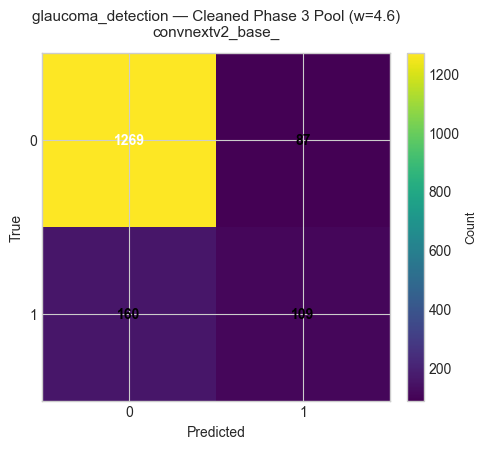

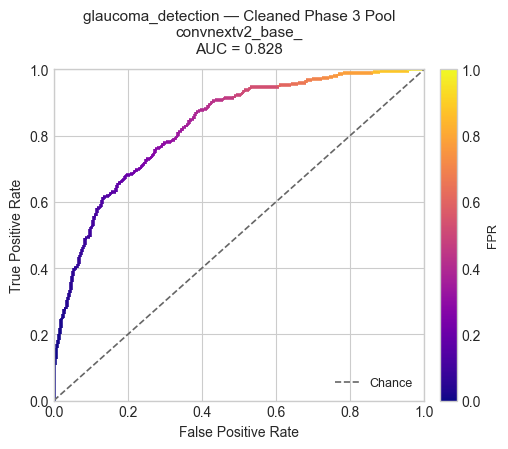


Embedding 2/7: dinov3_convnext_base
  Original dim: 1024 → Pooled: 2048 (mean+std)
  Train: 6436 patients | Test: 1625 patients
  Class dist (train): {np.int64(0): np.int64(5407), np.int64(1): np.int64(1029)} (16.0% positive)
  Running BayesSearchCV (30 iters)...


KeyboardInterrupt: 

In [5]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 5 — Phase 3 Execution: Patient Pooling + BayesSearchCV (cleaned data)
# ═══════════════════════════════════════════════════════════════════════════════
print('=' * 80)
print('PHASE 3 — Patient-Level Embedding Pooling (CLEANED BRSET)')
print(f'  Pooling: mean + std → 2×D')
print(f'  BayesSearchCV: {PHASE3_N_ITER} iters, {PHASE3_CV_FOLDS} CV, scoring=f1')
print(f'  Architectures: {len(PHASE3_ARCHITECTURES)}, weight search: 1.0–10.0')
print('=' * 80)

phase3_results = []
t0_total = time.time()

for emb_idx, emb_path in enumerate(embedding_files):
    sname = short_name(emb_path)
    print(f'\n{"="*80}')
    print(f'Embedding {emb_idx+1}/{len(embedding_files)}: {sname}')
    print(f'{"="*80}')

    t0 = time.time()

    # Load dataset
    ds = load_retina_embeddings_dataset(
        dataset=DATASET_NAME,
        embeddings_csv_path=emb_path,
        labels_csv_path=LABELS_PATH_CLEAN,
    )

    # Apply patient split
    df = ds.df.copy()
    df['patient_id'] = df['patient_id'].astype(str)
    train_df = df[df['patient_id'].isin(train_patient_ids)].dropna(subset=[TASK]).copy()
    test_df = df[df['patient_id'].isin(test_patient_ids)].dropna(subset=[TASK]).copy()

    # Build patient-level pooled features
    train_pids, X_train_pooled, y_train = build_patient_pooled_features(
        train_df, ds.feature_cols, group_col='patient_id', label_col=TASK
    )
    test_pids, X_test_pooled, y_test = build_patient_pooled_features(
        test_df, ds.feature_cols, group_col='patient_id', label_col=TASK
    )

    n_features_orig = len(ds.feature_cols)
    n_features_pooled = X_train_pooled.shape[1]

    classes, counts = np.unique(y_train, return_counts=True)
    pos_rate = counts[1] / counts.sum() if len(counts) > 1 else 0

    print(f'  Original dim: {n_features_orig} → Pooled: {n_features_pooled} (mean+std)')
    print(f'  Train: {len(y_train)} patients | Test: {len(y_test)} patients')
    print(f'  Class dist (train): {dict(zip(classes.astype(int), counts))} ({pos_rate:.1%} positive)')

    # Scale
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_pooled)
    X_test_scaled = scaler.transform(X_test_pooled)

    # Internal val split for threshold optimization
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_scaled, y_train, test_size=0.15, random_state=RANDOM_SEED, stratify=y_train
    )

    # Bayesian search
    base_mlp = MLPWrapperForBayesSearch(
        max_iter=PHASE3_MAX_EPOCHS,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=PHASE3_PATIENCE,
        random_state=RANDOM_SEED,
        warm_start=False,
    )

    bayes_search = BayesSearchCV(
        estimator=base_mlp,
        search_spaces=PHASE3_SEARCH_SPACE,
        n_iter=PHASE3_N_ITER,
        cv=PHASE3_CV_FOLDS,
        n_jobs=BAYES_N_JOBS,
        scoring='f1',
        random_state=RANDOM_SEED,
        verbose=0,
    )

    print(f'  Running BayesSearchCV ({PHASE3_N_ITER} iters)...')
    bayes_search.fit(X_train_scaled, y_train)

    best_model = bayes_search.best_estimator_
    best_params = bayes_search.best_params_
    best_cv_f1 = bayes_search.best_score_

    arch_idx = best_params.get('hidden_layer_sizes', 0)
    arch_display = PHASE3_ARCHITECTURES[arch_idx] if isinstance(arch_idx, int) else arch_idx
    best_weight = best_params.get('pos_class_weight', 1.0)

    print(f'  Best CV F1: {best_cv_f1:.4f}')
    print(f'  Architecture: {arch_display}')
    print(f'  pos_class_weight: {best_weight:.3f}')
    print(f'  alpha: {best_params.get("alpha", "?"):.6f}')
    print(f'  lr: {best_params.get("learning_rate_init", "?"):.6f}')
    print(f'  batch_size: {best_params.get("batch_size", "?")}')

    # F1-optimal threshold on internal validation
    val_proba = best_model.predict_proba(X_val)[:, 1]
    opt_thresh = find_optimal_threshold(y_val, val_proba, method='f1', grid_size=THRESHOLD_GRID_SIZE)
    print(f'  Optimal threshold: {opt_thresh:.3f}')

    # Evaluate on test patients
    y_proba_test = best_model.predict_proba(X_test_scaled)[:, 1]
    y_pred_test = (y_proba_test >= opt_thresh).astype(int)

    acc = (y_test == y_pred_test).mean()
    f1 = f1_score(y_test, y_pred_test, zero_division=0)
    prec = precision_score(y_test, y_pred_test, zero_division=0)
    rec = recall_score(y_test, y_pred_test, zero_division=0)
    bal_acc = balanced_accuracy_score(y_test, y_pred_test)
    fpr, tpr, _ = roc_curve(y_test, y_proba_test)
    auc = roc_auc_score(y_test, y_proba_test)

    elapsed = time.time() - t0
    print(f'\n  Patient-Level Metrics (DIRECT — no aggregation):')
    print(f'  F1 Score:          {f1:.3f}')
    print(f'  Precision:         {prec:.3f}')
    print(f'  Recall:            {rec:.3f}')
    print(f'  ROC AUC:           {auc:.3f}')
    print(f'  Balanced Accuracy: {bal_acc:.3f}')
    print(f'  Time: {elapsed:.0f}s')

    report_text = classification_report(y_test, y_pred_test, digits=3)
    print(f'\n{report_text}')

    cm = confusion_matrix(y_test, y_pred_test)

    # Save per-embedding results
    out_dir = RESULTS_DIR / f'{emb_idx:02d}_{sname}'
    out_dir.mkdir(parents=True, exist_ok=True)

    (out_dir / 'classification_report.txt').write_text(report_text, encoding='utf-8')

    hp_save = {k: str(v) for k, v in best_params.items()}
    hp_save['architecture_resolved'] = str(arch_display)
    hp_save['optimal_threshold'] = str(opt_thresh)
    hp_save['pooling_method'] = 'mean+std'
    hp_save['pooled_dim'] = str(n_features_pooled)
    hp_save['data'] = 'cleaned'
    with open(out_dir / 'hyperparameters.json', 'w') as f:
        json.dump(hp_save, f, indent=2)

    pd.DataFrame(cm).to_csv(out_dir / 'confusion_matrix.csv', index=False)
    plot_confusion_matrix(
        cm,
        title=f'{DISPLAY_TASK} — Cleaned Phase 3 Pool (w={best_weight:.1f})\n{sname}',
        save_path=out_dir / 'confusion_matrix.png' if SAVE_PLOTS else None,
        show=SHOW_PLOTS,
    )

    pd.DataFrame({'fpr': fpr, 'tpr': tpr}).to_csv(out_dir / 'roc_curve.csv', index=False)
    plot_roc_curve(
        fpr, tpr, auc,
        title=f'{DISPLAY_TASK} — Cleaned Phase 3 Pool\n{sname}',
        save_path=out_dir / 'roc_curve.png' if SAVE_PLOTS else None,
        show=SHOW_PLOTS,
    )

    pd.DataFrame({
        'patient_id': test_pids,
        'y_true': y_test,
        'y_pred': y_pred_test,
        'y_proba': y_proba_test,
    }).to_csv(out_dir / 'patient_predictions.csv', index=False)

    phase3_results.append({
        'embedding': sname,
        'data': 'cleaned',
        'pooling': 'mean+std',
        'pooled_dim': n_features_pooled,
        'architecture': str(arch_display),
        'pos_class_weight': float(best_weight),
        'threshold': float(opt_thresh),
        'n_train_patients': len(y_train),
        'n_test_patients': len(y_test),
        'best_cv_f1': float(best_cv_f1),
        'accuracy': float(acc),
        'balanced_accuracy': float(bal_acc),
        'f1_score': float(f1),
        'precision': float(prec),
        'recall': float(rec),
        'auc': float(auc),
        'time_s': float(elapsed),
    })

total_time = time.time() - t0_total
print(f'\n{"="*80}')
print(f'Phase 3 complete! Total time: {total_time:.0f}s ({total_time/60:.1f} min)')
print(f'{"="*80}')

## 6. Results Summary and Comparison with Original (Uncleaned) Phases 1-2

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 6 — Summary and Cross-Phase Comparison
# ═══════════════════════════════════════════════════════════════════════════════

p3c_df = pd.DataFrame(phase3_results).sort_values('f1_score', ascending=False)
p3c_df.to_csv(RESULTS_DIR / 'phase3_cleaned_summary.csv', index=False)

print('=' * 90)
print('PHASE 3 CLEANED RESULTS — Patient-Level Embedding Pooling (mean+std)')
print('=' * 90)
display(p3c_df[['embedding', 'pooled_dim', 'architecture', 'pos_class_weight',
                'threshold', 'f1_score', 'precision', 'recall', 'auc', 'balanced_accuracy']])

# ─── Load original Phase 1 & Phase 2 results ───
try:
    p1_df = pd.read_csv(RESULTS_DIR_ORIG / 'summary.csv')
    has_p1 = True
except FileNotFoundError:
    p1_df = pd.DataFrame()
    has_p1 = False

try:
    p2_df = pd.read_csv(RESULTS_DIR_ORIG / 'phase2_refinement' / 'phase2_summary.csv')
    has_p2 = True
except FileNotFoundError:
    p2_df = pd.DataFrame()
    has_p2 = False

# ─── Cross-phase comparison table ───
print('\n' + '=' * 90)
print('CROSS-PHASE COMPARISON — Best F1 per Embedding')
print('  P1 = Phase 1 (uncleaned, BayesSearchCV image-level)')
print('  P2 = Phase 2 (uncleaned, aggressive refinement)')
print('  P3c = Phase 3 cleaned (patient pooling, BayesSearchCV)')
print('=' * 90)
print(f'{"Embedding":<30} {"P1":>7} {"P2":>7} {"P3c":>7} {"Best":>7}  {"Δ(P3c-P2)":>10}')
print('-' * 90)

comparison_rows = []
for _, row in p3c_df.iterrows():
    emb = row['embedding']
    p3c_f1 = row['f1_score']
    p3c_auc = row['auc']

    # Phase 1 match
    p1_f1 = 0.0
    if has_p1:
        p1_match = p1_df[p1_df['embedding'].str.contains(emb.replace('_', ''), case=False)]
        p1_f1 = p1_match['f1_score'].max() if not p1_match.empty else 0

    # Phase 2 match
    p2_f1 = 0.0
    if has_p2:
        p2_match = p2_df[p2_df['embedding'] == emb]
        p2_f1 = p2_match['f1_score'].max() if not p2_match.empty else 0

    best_f1 = max(p1_f1, p2_f1, p3c_f1)
    best_phase = 'P1' if best_f1 == p1_f1 else ('P2' if best_f1 == p2_f1 else 'P3c')
    delta_p2 = p3c_f1 - max(p1_f1, p2_f1)

    print(f'  {emb:<28} {p1_f1:>6.3f}  {p2_f1:>6.3f}  {p3c_f1:>6.3f}  {best_f1:>6.3f}({best_phase:>3})  {delta_p2:>+9.3f}')

    comparison_rows.append({
        'embedding': emb,
        'phase1_f1': p1_f1,
        'phase2_f1': p2_f1,
        'phase3_cleaned_f1': p3c_f1,
        'phase3_cleaned_auc': p3c_auc,
        'best_f1': best_f1,
        'best_phase': best_phase,
        'delta_vs_best_uncleaned': delta_p2,
    })

comp_df = pd.DataFrame(comparison_rows)
comp_df.to_csv(RESULTS_DIR / 'cross_phase_comparison.csv', index=False)

# ─── Clinical viability check ───
print('\n' + '=' * 90)
print('CLINICAL VIABILITY CHECK:')
print('=' * 90)
for _, row in p3c_df.iterrows():
    emb = row['embedding']
    f1 = row['f1_score']
    rec = row['recall']
    auc = row['auc']
    if f1 >= 0.80:
        status = '*** CLINICAL GRADE ***'
    elif f1 >= 0.70:
        status = 'APPROACHING'
    elif f1 >= 0.60:
        status = 'MODERATE'
    else:
        status = 'NEEDS IMPROVEMENT'
    print(f'  {emb}: F1={f1:.3f}  Recall={rec:.3f}  AUC={auc:.3f}  [{status}]')

# ─── Best overall ───
best = p3c_df.iloc[0]
print(f'\n*** BEST: {best["embedding"]}  F1={best["f1_score"]:.3f}  AUC={best["auc"]:.3f} ***')
print(f'Saved: {RESULTS_DIR / "phase3_cleaned_summary.csv"}')

## 7. Visualization — F1 and AUC Comparison

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════════
# Cell 7 — Bar Chart Comparison
# ═══════════════════════════════════════════════════════════════════════════════

embeddings_short = p3c_df.sort_values('f1_score', ascending=False)['embedding'].tolist()
x = np.arange(len(embeddings_short))
width = 0.25

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ─── F1 comparison ───
ax = axes[0]
p1_f1s, p2_f1s, p3c_f1s = [], [], []
for emb in embeddings_short:
    if has_p1:
        p1_m = p1_df[p1_df['embedding'].str.contains(emb.replace('_', ''), case=False)]
        p1_f1s.append(p1_m['f1_score'].max() if not p1_m.empty else 0)
    else:
        p1_f1s.append(0)

    if has_p2:
        p2_m = p2_df[p2_df['embedding'] == emb]
        p2_f1s.append(p2_m['f1_score'].max() if not p2_m.empty else 0)
    else:
        p2_f1s.append(0)

    p3c_f1s.append(p3c_df[p3c_df['embedding'] == emb]['f1_score'].values[0])

bars1 = ax.bar(x - width, p1_f1s, width, label='Phase 1 (uncleaned)', color='#2E86AB', alpha=0.85)
bars2 = ax.bar(x, p2_f1s, width, label='Phase 2 (uncleaned)', color='#A23B72', alpha=0.85)
bars3 = ax.bar(x + width, p3c_f1s, width, label='Phase 3 (cleaned pooling)', color='#F18F01', alpha=0.85)
ax.axhline(y=0.80, color='red', linestyle='--', linewidth=1.5, label='Clinical target (0.80)')
ax.set_xlabel('Embedding', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1: Uncleaned Phases 1-2 vs Cleaned Phase 3 (Patient Pooling)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(embeddings_short, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

# Add value labels on P3c bars
for bar, val in zip(bars3, p3c_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

# ─── AUC comparison ───
ax = axes[1]
p1_aucs, p3c_aucs = [], []
for emb in embeddings_short:
    if has_p1:
        p1_m = p1_df[p1_df['embedding'].str.contains(emb.replace('_', ''), case=False)]
        p1_aucs.append(p1_m['auc'].max() if not p1_m.empty else 0)
    else:
        p1_aucs.append(0)
    p3c_aucs.append(p3c_df[p3c_df['embedding'] == emb]['auc'].values[0])

bars1 = ax.bar(x - width/2, p1_aucs, width, label='Phase 1 (uncleaned)', color='#2E86AB', alpha=0.85)
bars3 = ax.bar(x + width/2, p3c_aucs, width, label='Phase 3 (cleaned pooling)', color='#F18F01', alpha=0.85)
ax.set_xlabel('Embedding', fontsize=11)
ax.set_ylabel('AUC', fontsize=11)
ax.set_title('ROC AUC: Uncleaned Phase 1 vs Cleaned Phase 3', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(embeddings_short, rotation=45, ha='right', fontsize=8)
ax.legend(fontsize=9)
ax.set_ylim(0.7, 1.0)
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars3, p3c_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'cleaned_vs_uncleaned_comparison.png', dpi=160, bbox_inches='tight')
plt.show()

print(f'\nSaved: {RESULTS_DIR / "cleaned_vs_uncleaned_comparison.png"}')